# Exploration du zip `donnee_cerco`

Ce notebook :
- détecte le zip `donnee_cerco*.zip` ;
- explore la structure des fichiers ;
- lit des données de signaux (multi-formats) ;
- affiche des figures illustratives de la structure des canaux ;
- produit une figure **brut vs préprocessé**.

In [3]:
from pathlib import Path
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('default')
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_colwidth', 120)

In [4]:
# --- Configuration chemins ---
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
ZIP_NAME_HINT = 'donnee_cerco'

# Recherche d'abord dans le workspace, puis dans Téléchargements
workspace_candidates = sorted(PROJECT_ROOT.rglob(f'*{ZIP_NAME_HINT}*.zip'))
downloads_dir = Path.home() / 'Downloads'
download_candidates = sorted(downloads_dir.rglob(f'*{ZIP_NAME_HINT}*.zip')) if downloads_dir.exists() else []

zip_candidates = workspace_candidates + [p for p in download_candidates if p not in workspace_candidates]

if not zip_candidates:
    raise FileNotFoundError(
        f"Aucun zip contenant '{ZIP_NAME_HINT}' trouvé ni dans {PROJECT_ROOT} ni dans {downloads_dir}. "
        "Placez votre fichier (ex: donnee_cerco.zip) dans le workspace ou dans Téléchargements puis relancez."
    )

ZIP_PATH = zip_candidates[0]
EXTRACT_DIR = PROJECT_ROOT / 'data' / 'raw' / ZIP_PATH.stem

print('PROJECT_ROOT :', PROJECT_ROOT)
print('Downloads    :', downloads_dir)
print('ZIP_PATH     :', ZIP_PATH)
print('EXTRACT_DIR  :', EXTRACT_DIR)

PROJECT_ROOT : C:\dev\Cerco_studies
Downloads    : C:\Users\U1108091\Downloads
ZIP_PATH     : C:\Users\U1108091\Downloads\donnee_cerco.zip
EXTRACT_DIR  : C:\dev\Cerco_studies\data\raw\donnee_cerco


In [5]:
# --- Inventaire du zip ---
with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    infos = [
        {
            'path': i.filename,
            'size_bytes': i.file_size,
            'compress_size_bytes': i.compress_size,
        }
        for i in zf.infolist()
        if not i.is_dir()
    ]

files_df = pd.DataFrame(infos)
files_df['ext'] = files_df['path'].apply(lambda p: Path(p).suffix.lower())
files_df['n_levels'] = files_df['path'].str.count('/') + 1
files_df['top_folder'] = files_df['path'].apply(lambda p: p.split('/')[0] if '/' in p else '(root)')

print(f'Nombre de fichiers: {len(files_df)}')
display(files_df.head(20))
display(files_df['ext'].value_counts().rename('count').to_frame().head(20))

Nombre de fichiers: 76


,path,size_bytes,compress_size_bytes,ext,n_levels,top_folder
0,data_raw_fif/AE129/AE129_raw.fif,792629909,792629909,.fif,3,data_raw_fif
1,data_raw_fif/AN166/AN166_raw.fif,599981413,599981413,.fif,3,data_raw_fif
2,data_raw_fif/BA152/BA152_raw.fif,575513110,575513110,.fif,3,data_raw_fif
3,data_raw_fif/BA171/BA171_raw.fif,588403611,588403611,.fif,3,data_raw_fif
4,data_raw_fif/BB114/BB114_raw.fif,645497546,645497546,.fif,3,data_raw_fif
5,data_raw_fif/BDRE44/BDRE44_raw.fif,787765200,787765200,.fif,3,data_raw_fif
6,data_raw_fif/BF181/BF181_raw.fif,596818428,596818428,.fif,3,data_raw_fif
7,data_raw_fif/BJ138/BJ138_raw.fif,630153693,630153693,.fif,3,data_raw_fif
8,data_raw_fif/BO60/BO60_raw.fif,615347459,615347459,.fif,3,data_raw_fif
9,data_raw_fif/CA169/CA169_raw.fif,730101952,730101952,.fif,3,data_raw_fif


,count
ext,
.fif,76


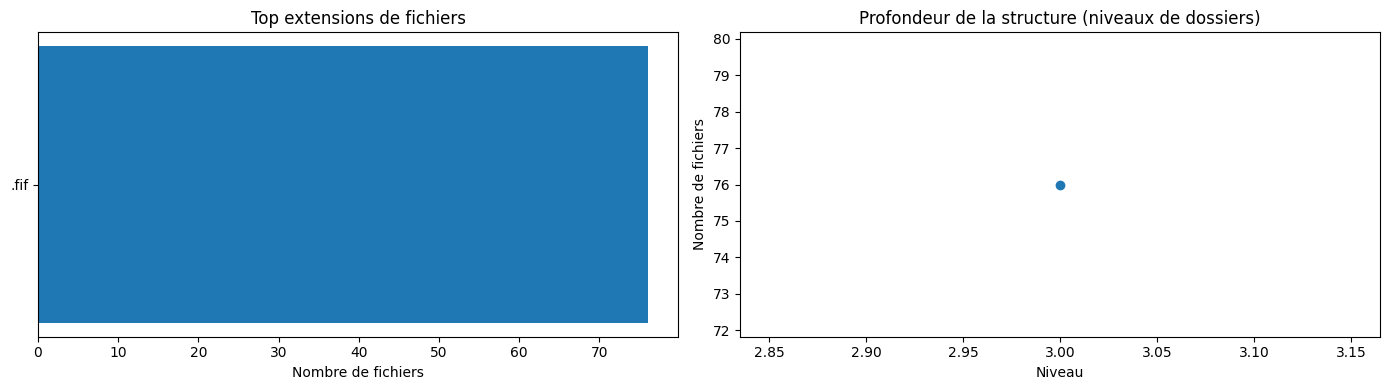

,count
top_folder,
data_raw_fif,76


In [6]:
# --- Figures structure des données ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ext_counts = files_df['ext'].value_counts().head(12).sort_values()
axes[0].barh(ext_counts.index.astype(str), ext_counts.values)
axes[0].set_title('Top extensions de fichiers')
axes[0].set_xlabel('Nombre de fichiers')

depth_counts = files_df['n_levels'].value_counts().sort_index()
axes[1].plot(depth_counts.index, depth_counts.values, marker='o')
axes[1].set_title('Profondeur de la structure (niveaux de dossiers)')
axes[1].set_xlabel('Niveau')
axes[1].set_ylabel('Nombre de fichiers')

plt.tight_layout()
plt.show()

display(files_df.groupby('top_folder').size().sort_values(ascending=False).rename('count').to_frame())

In [8]:
# --- Extraction (si nécessaire) ---
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

already_extracted = any(EXTRACT_DIR.rglob('*'))
if not already_extracted:
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(EXTRACT_DIR)
    print('Extraction terminée.')
else:
    print('Données déjà extraites, extraction sautée.')

all_files = [p for p in EXTRACT_DIR.rglob('*') if p.is_file()]
print(f'Fichiers extraits: {len(all_files)}')

Données déjà extraites, extraction sautée.
Fichiers extraits: 76


In [12]:
# --- Lecture signal multi-format (générique) ---
def _to_2d(arr):
    arr = np.asarray(arr)
    if arr.ndim == 1:
        arr = arr[:, None]
    if arr.ndim > 2:
        arr = arr.reshape(arr.shape[0], -1)
    # Heuristique: on veut [n_samples, n_channels]
    if arr.shape[0] < arr.shape[1]:
        arr = arr.T
    return arr

def read_signal(file_path: Path):
    suffix = file_path.suffix.lower()

    if suffix in {'.npy', '.npz'}:
        obj = np.load(file_path, allow_pickle=True)
        if isinstance(obj, np.lib.npyio.NpzFile):
            key = obj.files[0]
            data = obj[key]
        else:
            data = obj
        arr = _to_2d(data)
        ch_names = [f'ch_{i+1}' for i in range(arr.shape[1])]
        return arr, ch_names

    if suffix in {'.csv', '.txt', '.tsv'}:
        sep = '\t' if suffix == '.tsv' else None
        df = pd.read_csv(file_path, sep=sep, engine='python')
        num_df = df.select_dtypes(include=[np.number])
        if num_df.empty:
            raise ValueError(f'Pas de colonnes numériques dans {file_path.name}')
        arr = _to_2d(num_df.to_numpy())
        ch_names = list(num_df.columns)
        return arr, ch_names

    if suffix == '.mat':
        from scipy.io import loadmat
        mat = loadmat(file_path)
        candidates = [v for k, v in mat.items() if not k.startswith('__') and isinstance(v, np.ndarray)]
        if not candidates:
            raise ValueError(f'Aucun tableau exploitable dans {file_path.name}')
        data = max(candidates, key=lambda x: x.size)
        arr = _to_2d(data)
        ch_names = [f'ch_{i+1}' for i in range(arr.shape[1])]
        return arr, ch_names

    if suffix in {'.edf', '.bdf', '.fif'}:
        import mne
        if suffix == '.fif':
            raw = mne.io.read_raw_fif(file_path, preload=True, verbose='ERROR')
        else:
            raw = mne.io.read_raw_edf(file_path, preload=True, verbose='ERROR')
        data = raw.get_data().T  # [n_samples, n_channels]
        ch_names = raw.ch_names
        return data, ch_names

    raise NotImplementedError(f'Format non supporté: {suffix}')

signal_exts = {'.npy', '.npz', '.csv', '.txt', '.tsv', '.mat', '.edf', '.bdf', '.fif'}
signal_candidates = [p for p in all_files if p.suffix.lower() in signal_exts]
print(f'Candidats signal détectés: {len(signal_candidates)}')
signal_candidates[:10]

Candidats signal détectés: 76


[WindowsPath('C:/dev/Cerco_studies/data/raw/donnee_cerco/data_raw_fif/AE129/AE129_raw.fif'),
 WindowsPath('C:/dev/Cerco_studies/data/raw/donnee_cerco/data_raw_fif/AN166/AN166_raw.fif'),
 WindowsPath('C:/dev/Cerco_studies/data/raw/donnee_cerco/data_raw_fif/BA152/BA152_raw.fif'),
 WindowsPath('C:/dev/Cerco_studies/data/raw/donnee_cerco/data_raw_fif/BA171/BA171_raw.fif'),
 WindowsPath('C:/dev/Cerco_studies/data/raw/donnee_cerco/data_raw_fif/BB114/BB114_raw.fif'),
 WindowsPath('C:/dev/Cerco_studies/data/raw/donnee_cerco/data_raw_fif/BDRE44/BDRE44_raw.fif'),
 WindowsPath('C:/dev/Cerco_studies/data/raw/donnee_cerco/data_raw_fif/BF181/BF181_raw.fif'),
 WindowsPath('C:/dev/Cerco_studies/data/raw/donnee_cerco/data_raw_fif/BJ138/BJ138_raw.fif'),
 WindowsPath('C:/dev/Cerco_studies/data/raw/donnee_cerco/data_raw_fif/BO60/BO60_raw.fif'),
 WindowsPath('C:/dev/Cerco_studies/data/raw/donnee_cerco/data_raw_fif/CA169/CA169_raw.fif')]

Fichier exemple : C:\dev\Cerco_studies\data\raw\donnee_cerco\data_raw_fif\AE129\AE129_raw.fif
Shape          : (9428992, 21) [n_samples, n_channels]


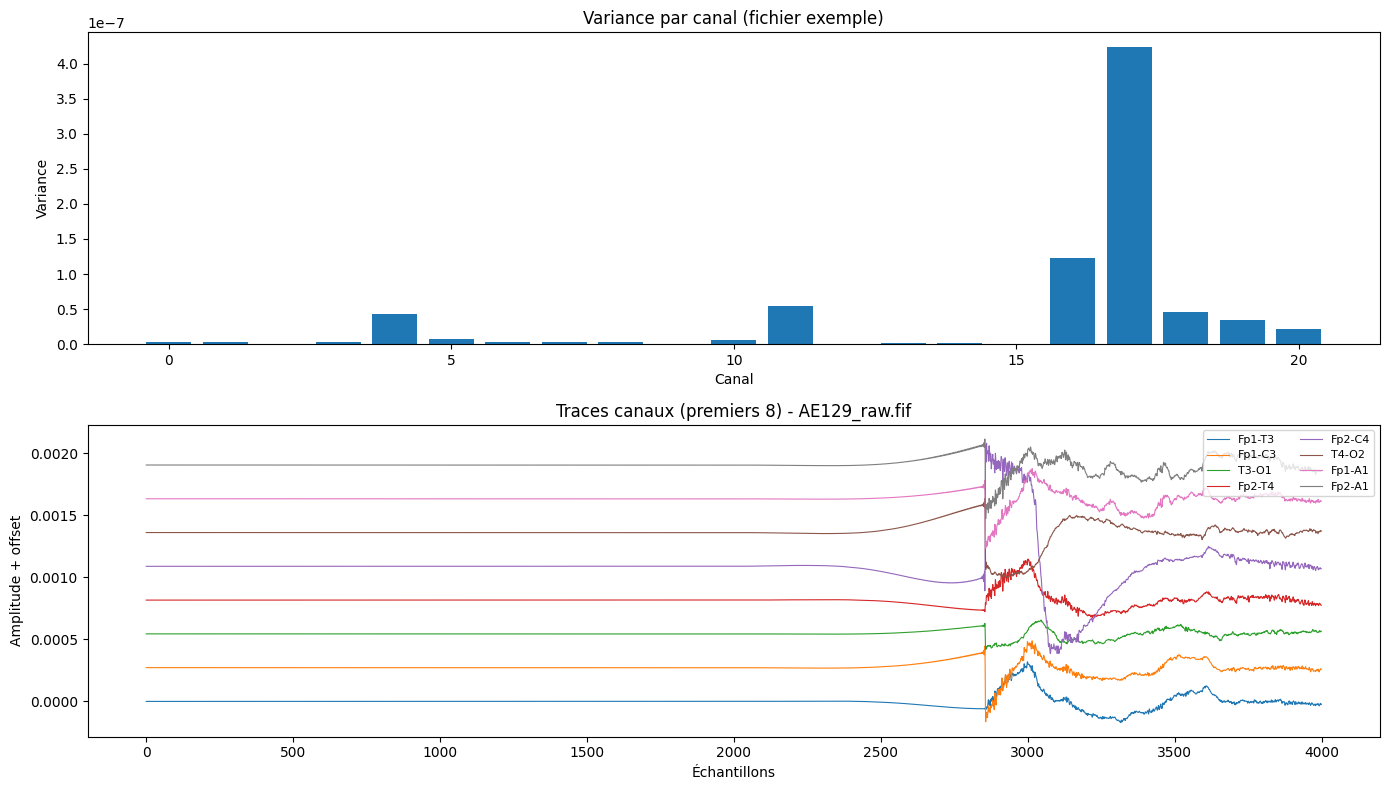

In [13]:
# --- Figure: structure des canaux sur un fichier exemple ---
if not signal_candidates:
    raise RuntimeError('Aucun fichier signal détecté. Vérifiez les extensions ou adaptez read_signal().')

example_file = signal_candidates[0]
data_ex, ch_ex = read_signal(example_file)

print('Fichier exemple :', example_file)
print('Shape          :', data_ex.shape, '[n_samples, n_channels]')

n_plot = min(8, data_ex.shape[1])
segment = min(4000, data_ex.shape[0])
t = np.arange(segment)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

# Variance par canal
channel_var = data_ex[:segment, :].var(axis=0)
axes[0].bar(np.arange(len(channel_var)), channel_var)
axes[0].set_title('Variance par canal (fichier exemple)')
axes[0].set_xlabel('Canal')
axes[0].set_ylabel('Variance')

# Traces empilées
offset = np.nanstd(data_ex[:segment, :n_plot]) * 3 if np.nanstd(data_ex[:segment, :n_plot]) > 0 else 1.0
for i in range(n_plot):
    axes[1].plot(t, data_ex[:segment, i] + i * offset, lw=0.8, label=ch_ex[i] if i < len(ch_ex) else f'ch_{i+1}')
axes[1].set_title(f'Traces canaux (premiers {n_plot}) - {example_file.name}')
axes[1].set_xlabel('Échantillons')
axes[1].set_ylabel('Amplitude + offset')
axes[1].legend(loc='upper right', ncol=2, fontsize=8)

plt.tight_layout()
plt.show()

In [15]:
# --- Analyse d'un fichier : type des canaux ---
# Tu peux forcer un fichier en remplaçant ANALYSIS_FILE = signal_candidates[0] par un Path(...)
ANALYSIS_FILE = signal_candidates[0]

print('Fichier analysé :', ANALYSIS_FILE)

suffix = Path(ANALYSIS_FILE).suffix.lower()

if suffix in {'.fif', '.edf', '.bdf'}:
    import mne

    if suffix == '.fif':
        raw_analysis = mne.io.read_raw_fif(ANALYSIS_FILE, preload=False, verbose='ERROR')
    else:
        raw_analysis = mne.io.read_raw_edf(ANALYSIS_FILE, preload=False, verbose='ERROR')

    channel_info = pd.DataFrame({
        'channel_name': raw_analysis.ch_names,
        'channel_type_mne': raw_analysis.get_channel_types(),
    })
else:
    _, ch_tmp = read_signal(Path(ANALYSIS_FILE))
    channel_info = pd.DataFrame({
        'channel_name': ch_tmp,
        'channel_type_mne': ['unknown(non-MNE format)'] * len(ch_tmp),
    })


def infer_channel_family(name: str) -> str:
    n = str(name).upper()
    if 'EMG' in n or 'MENTON' in n or 'JAMB' in n:
        return 'emg'
    if 'EOG' in n:
        return 'eog'
    if 'ECG' in n or 'EKG' in n:
        return 'ecg'
    if 'RONF' in n or 'SNOR' in n:
        return 'resp/snore'
    return 'eeg'


channel_info['channel_family_guess'] = channel_info['channel_name'].apply(infer_channel_family)

print('\nRésumé des types MNE:')
display(channel_info['channel_type_mne'].value_counts().rename('count').to_frame())

print('\nRésumé des familles (déduites par nom):')
display(channel_info['channel_family_guess'].value_counts().rename('count').to_frame())

print('\nDétail canal par canal:')
display(channel_info)

Fichier analysé : C:\dev\Cerco_studies\data\raw\donnee_cerco\data_raw_fif\AE129\AE129_raw.fif

Résumé des types MNE:


,count
channel_type_mne,
eeg,21



Résumé des familles (déduites par nom):


,count
channel_family_guess,
eeg,12
emg,5
eog,2
resp/snore,1
ecg,1



Détail canal par canal:


,channel_name,channel_type_mne,channel_family_guess
0,Fp1-T3,eeg,eeg
1,Fp1-C3,eeg,eeg
2,T3-O1,eeg,eeg
3,Fp2-T4,eeg,eeg
4,Fp2-C4,eeg,eeg
5,T4-O2,eeg,eeg
6,Fp1-A1,eeg,eeg
7,Fp2-A1,eeg,eeg
8,T3-A1,eeg,eeg
9,C3-A1,eeg,eeg


Détection auto incomplète. Sélection fallback sur 2 fichiers candidats.


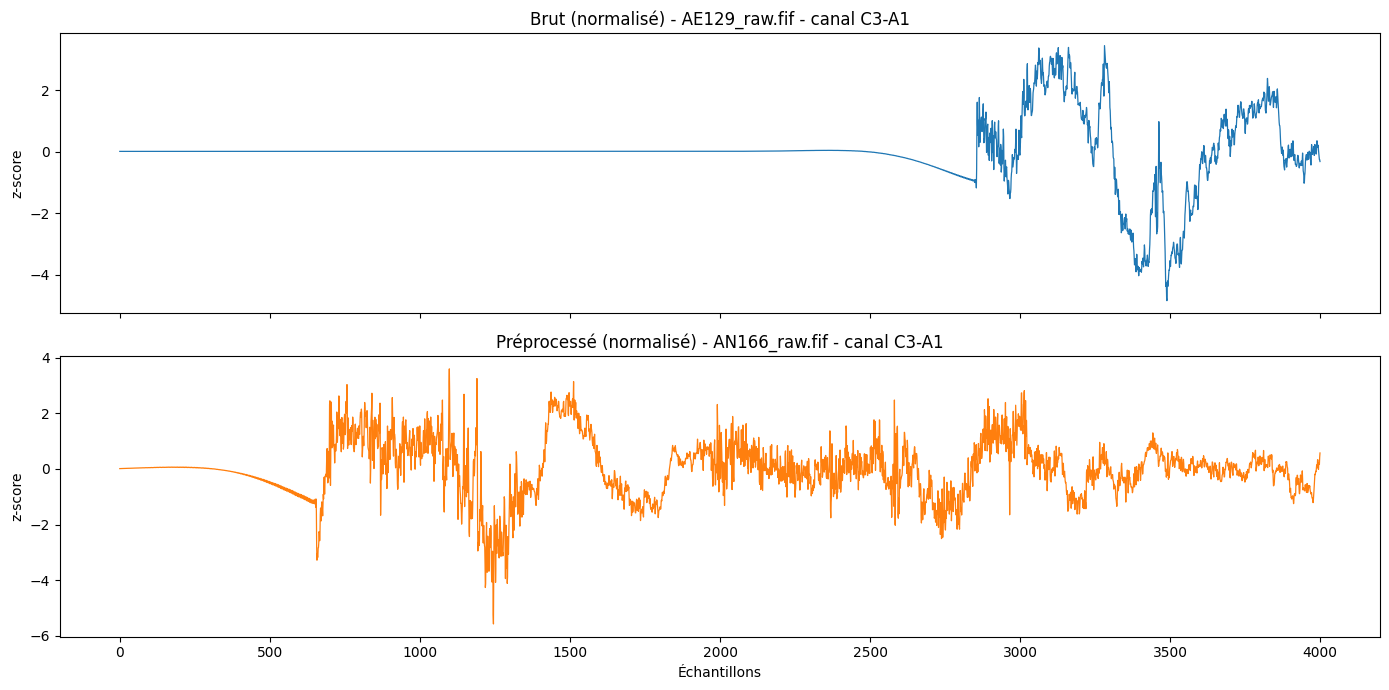

RAW_FILE    : C:\dev\Cerco_studies\data\raw\donnee_cerco\data_raw_fif\AE129\AE129_raw.fif
PREPROC_FILE: C:\dev\Cerco_studies\data\raw\donnee_cerco\data_raw_fif\AN166\AN166_raw.fif


In [11]:
# --- Figure: brut vs préprocessé ---
# Détection automatique via mots-clés; sinon forcer avec RAW_FILE / PREPROC_FILE
RAW_FILE = None
PREPROC_FILE = None

raw_kw = ('raw', 'brut', 'unprocessed', 'original')
pre_kw = ('preprocess', 'preproc', 'processed', 'clean', 'filtered')

if RAW_FILE is None:
    raw_matches = [p for p in signal_candidates if any(k in p.as_posix().lower() for k in raw_kw)]
    RAW_FILE = raw_matches[0] if raw_matches else None

if PREPROC_FILE is None:
    pre_matches = [p for p in signal_candidates if any(k in p.as_posix().lower() for k in pre_kw)]
    PREPROC_FILE = pre_matches[0] if pre_matches else None

if RAW_FILE is None or PREPROC_FILE is None:
    print('Détection auto incomplète. Sélection fallback sur 2 fichiers candidats.')
    if len(signal_candidates) >= 2:
        RAW_FILE = RAW_FILE or signal_candidates[0]
        PREPROC_FILE = PREPROC_FILE or signal_candidates[1]
    else:
        raise RuntimeError('Impossible de former une paire brut/préprocessé (moins de 2 fichiers).')

raw_data, raw_ch = read_signal(Path(RAW_FILE))
pre_data, pre_ch = read_signal(Path(PREPROC_FILE))

n_samples = min(raw_data.shape[0], pre_data.shape[0], 4000)
raw_data = raw_data[:n_samples]
pre_data = pre_data[:n_samples]

# Choix canal commun par nom si possible, sinon canal 0
common = list(set(raw_ch).intersection(pre_ch))
if common:
    ch_name = sorted(common)[0]
    i_raw = raw_ch.index(ch_name)
    i_pre = pre_ch.index(ch_name)
else:
    ch_name = 'ch_1'
    i_raw = 0
    i_pre = 0

x_raw = raw_data[:, i_raw]
x_pre = pre_data[:, i_pre]

# Normalisation z-score pour comparaison visuelle
def zscore(x):
    s = np.nanstd(x)
    return (x - np.nanmean(x)) / s if s > 0 else x

x_raw_z = zscore(x_raw)
x_pre_z = zscore(x_pre)

t = np.arange(n_samples)
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(t, x_raw_z, color='tab:blue', lw=0.9)
axes[0].set_title(f'Brut (normalisé) - {Path(RAW_FILE).name} - canal {ch_name}')
axes[0].set_ylabel('z-score')

axes[1].plot(t, x_pre_z, color='tab:orange', lw=0.9)
axes[1].set_title(f'Préprocessé (normalisé) - {Path(PREPROC_FILE).name} - canal {ch_name}')
axes[1].set_xlabel('Échantillons')
axes[1].set_ylabel('z-score')

plt.tight_layout()
plt.show()

print('RAW_FILE    :', RAW_FILE)
print('PREPROC_FILE:', PREPROC_FILE)